# Global Superstore Sales Dashboard and Business Analysis

## Problem Statement and Objective

The objective of this task is to analyze the Global Superstore dataset and create useful business insights from sales, profit, customers, products, categories, regions, and segments.

This task focuses on:

- Dataset loading and cleaning
- Exploratory Data Analysis
- KPI calculation
- Sales and profit visualizations
- Customer and product analysis
- Business insights and recommendations

The final analysis helps understand business performance and supports better decision-making.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Description and Loading

The dataset used in this task is the Global Superstore dataset.

It contains sales transaction data including:

- Order information
- Customer information
- Product details
- Sales
- Profit
- Quantity
- Discount
- Shipping cost
- Region
- Market
- Segment
- Category and Sub-Category

The dataset is loaded using pandas.

In [2]:
# Load dataset
file_name = "Global Superstore.csv"

data = pd.read_csv(file_name, encoding="latin1")

# Display first 5 rows
data.head()
# Dataset shape
print("Dataset shape:", data.shape)
# Dataset information
data.info()
# Display column names
data.columns
# Statistical summary
data.describe()

Dataset shape: (51290, 27)
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer.ID     51290 non-null  str    
 4   Customer.Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   è®°å½æ°       51290 non-null  int64  
 8   Order.Date      51290 non-null  str    
 9   Order.ID        51290 non-null  str    
 10  Order.Priority  51290 non-null  str    
 11  Product.ID      51290 non-null  str    
 12  Product.Name    51290 non-null  str    
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  str    
 16  Row.ID          51290 non-null  int64  
 17  Sales          

,Discount,è®°å½æ°,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


## Data Cleaning and Preprocessing

In this section, the dataset is cleaned before analysis.

The following steps are performed:

- Remove extra spaces from column names
- Rename columns for easier use
- Convert date columns into datetime format
- Convert numeric columns into numeric format
- Remove unreadable unnecessary columns
- Drop rows with missing important values

In [3]:
# Remove extra spaces from column names
data.columns = data.columns.str.strip()

# Rename columns to easier names
data.rename(columns={
    "Customer.Name": "Customer Name",
    "Sub.Category": "Sub-Category",
    "Order.Date": "Order Date",
    "Order.ID": "Order ID",
    "Ship.Date": "Ship Date",
    "Shipping.Cost": "Shipping Cost",
    "Product.Name": "Product Name",
    "Product.ID": "Product ID",
    "Customer.ID": "Customer ID",
    "Order.Priority": "Order Priority",
    "Ship.Mode": "Ship Mode",
    "Row.ID": "Row ID"
}, inplace=True)

# Display updated columns
data.columns

Index(['Category', 'City', 'Country', 'Customer ID', 'Customer Name',
       'Discount', 'Market', 'è®°å½æ°', 'Order Date', 'Order ID',
       'Order Priority', 'Product ID', 'Product Name', 'Profit', 'Quantity',
       'Region', 'Row ID', 'Sales', 'Segment', 'Ship Date', 'Ship Mode',
       'Shipping Cost', 'State', 'Sub-Category', 'Year', 'Market2', 'weeknum'],
      dtype='str')

In [4]:
# Convert date columns
data["Order Date"] = pd.to_datetime(data["Order Date"], errors="coerce")
data["Ship Date"] = pd.to_datetime(data["Ship Date"], errors="coerce")

# Convert numeric columns
numeric_columns = ["Sales", "Profit", "Quantity", "Discount", "Shipping Cost"]

for col in numeric_columns:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

In [5]:
# Drop unnecessary unreadable columns if present
for col in data.columns:
    if "è" in col or "®" in col:
        data.drop(columns=[col], inplace=True)

# Drop rows with missing important values
important_columns = [
    "Sales",
    "Profit",
    "Region",
    "Category",
    "Sub-Category",
    "Customer Name"
]

data = data.dropna(subset=important_columns)

# Check missing values after cleaning
data.isnull().sum()

Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
Product Name      0
Profit            0
Quantity          0
Region            0
Row ID            0
Sales             0
Segment           0
Ship Date         0
Ship Mode         0
Shipping Cost     0
State             0
Sub-Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [6]:
# Dataset shape after cleaning
print("Cleaned dataset shape:", data.shape)

Cleaned dataset shape: (51290, 26)


## Exploratory Data Analysis

EDA is used to understand business data patterns.

In this section, we analyze:

- Region distribution
- Category distribution
- Segment distribution
- Sales and profit patterns

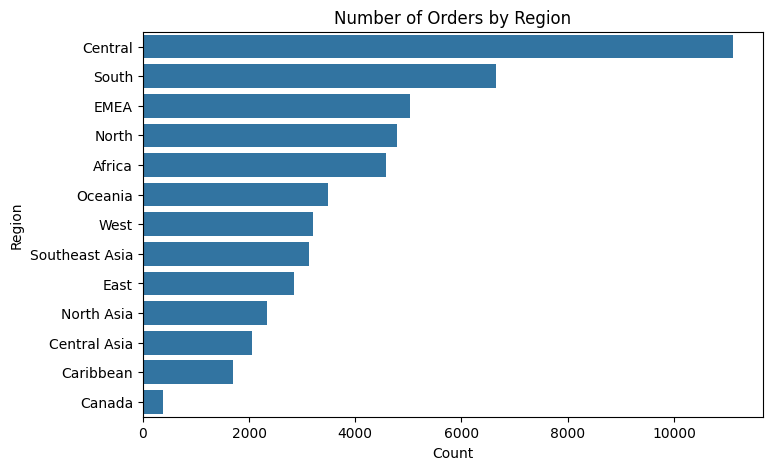

In [7]:
# Region count
plt.figure(figsize=(8, 5))
sns.countplot(y="Region", data=data, order=data["Region"].value_counts().index)
plt.title("Number of Orders by Region")
plt.xlabel("Count")
plt.ylabel("Region")
plt.show()

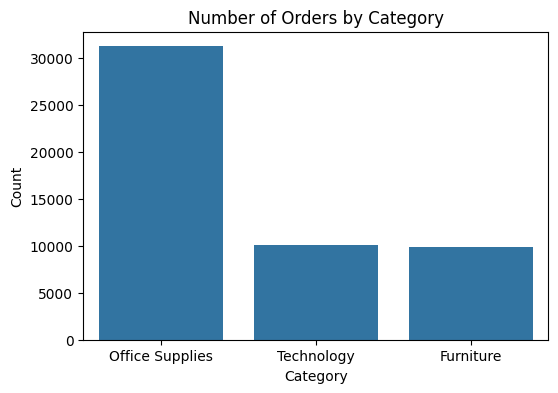

In [8]:
# Category count
plt.figure(figsize=(6, 4))
sns.countplot(x="Category", data=data, order=data["Category"].value_counts().index)
plt.title("Number of Orders by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

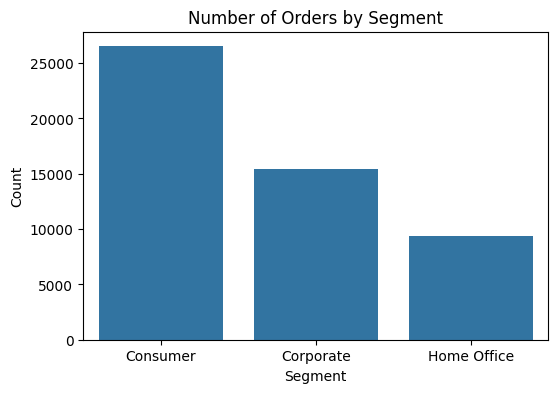

In [9]:
# Segment count
plt.figure(figsize=(6, 4))
sns.countplot(x="Segment", data=data, order=data["Segment"].value_counts().index)
plt.title("Number of Orders by Segment")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

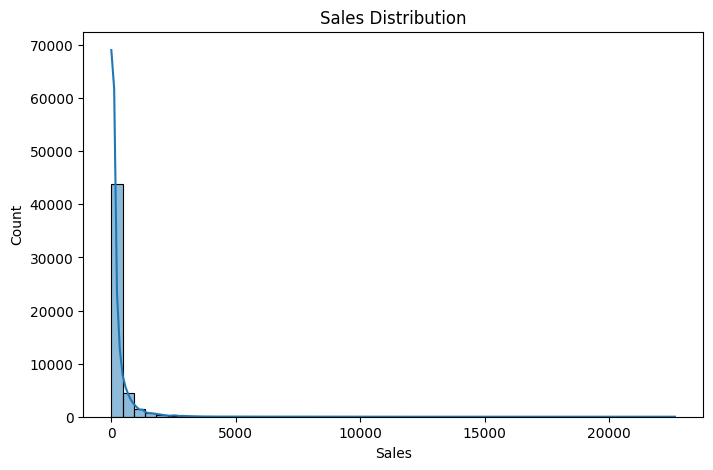

In [10]:
# Sales distribution
plt.figure(figsize=(8, 5))
sns.histplot(data["Sales"], bins=50, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.show()

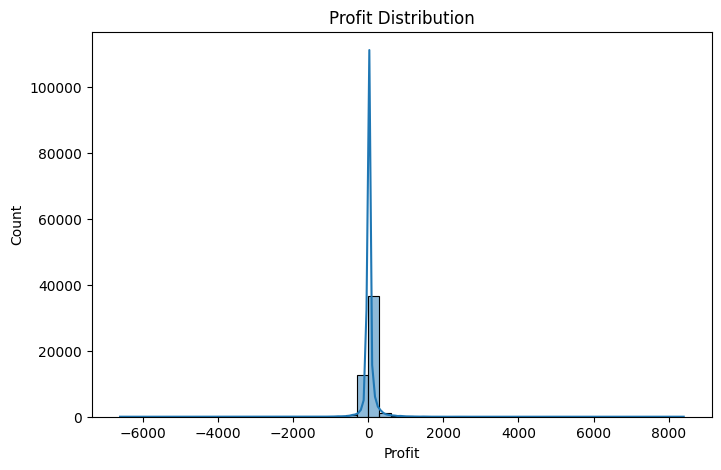

In [11]:
# Profit distribution
plt.figure(figsize=(8, 5))
sns.histplot(data["Profit"], bins=50, kde=True)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Count")
plt.show()

## Key Performance Indicators

KPIs provide a quick summary of business performance.

The calculated KPIs are:

- Total Sales
- Total Profit
- Total Orders
- Total Customers
- Profit Margin
- Total Quantity
- Average Discount
- Total Shipping Cost

In [12]:
# KPI calculations
total_sales = data["Sales"].sum()
total_profit = data["Profit"].sum()
total_orders = data["Order ID"].nunique()
total_customers = data["Customer Name"].nunique()
total_quantity = data["Quantity"].sum()
average_discount = data["Discount"].mean()
total_shipping_cost = data["Shipping Cost"].sum()

if total_sales != 0:
    profit_margin = (total_profit / total_sales) * 100
else:
    profit_margin = 0

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Profit Margin (%)",
        "Total Quantity",
        "Average Discount",
        "Total Shipping Cost"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_orders,
        total_customers,
        profit_margin,
        total_quantity,
        average_discount,
        total_shipping_cost
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,1.264290e+07
1,Total Profit,1.467457e+06
2,Total Orders,2.503500e+04
3,Total Customers,7.950000e+02
4,Profit Margin (%),1.160696e+01
5,Total Quantity,1.783120e+05
6,Average Discount,1.429075e-01
7,Total Shipping Cost,1.352816e+06


## Sales by Region

This analysis shows which regions generate the highest sales.

In [13]:
sales_by_region = (
    data.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_region

Region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
EMEA               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: Sales, dtype: int64

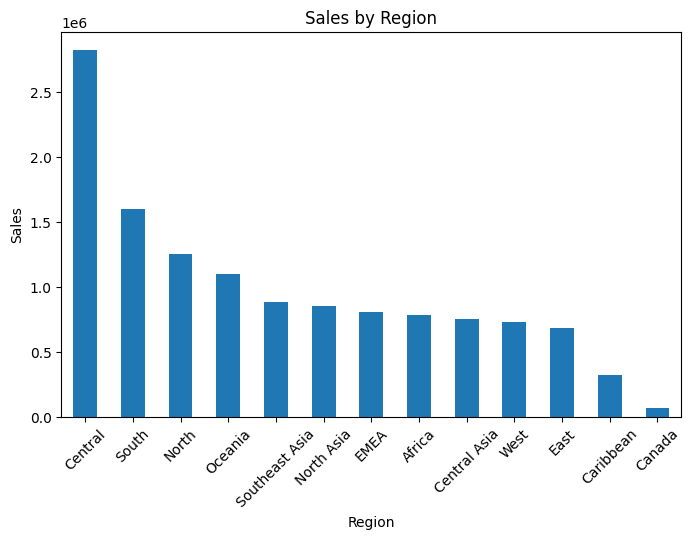

In [14]:
plt.figure(figsize=(8, 5))
sales_by_region.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

## Sales by Category

This analysis shows which product categories generate the highest sales.

In [15]:
sales_by_category = (
    data.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_category

Category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: Sales, dtype: int64

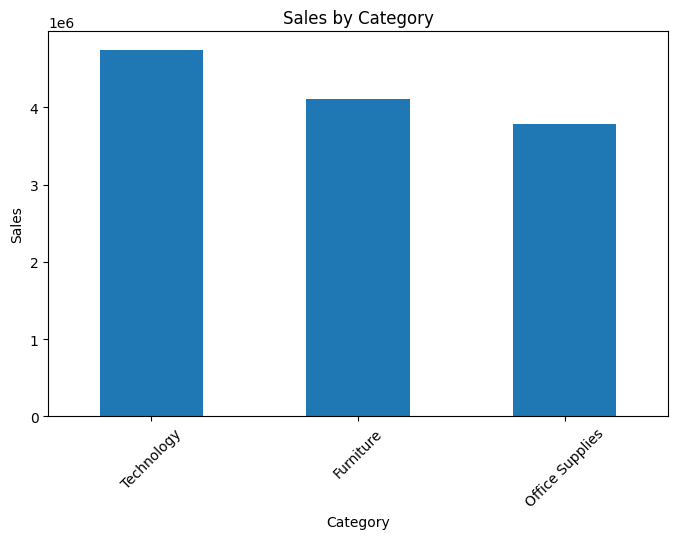

In [16]:
plt.figure(figsize=(8, 5))
sales_by_category.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

## Profit by Sub-Category

This analysis identifies which sub-categories are most profitable and which may need business review.

In [17]:
profit_by_subcategory = (
    data.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_subcategory

Sub-Category
Copiers        258567.54818
Phones         216717.00580
Bookcases      161924.41950
Appliances     141680.58940
Chairs         140396.26750
Accessories    129626.30620
Storage        108461.48980
Binders         72449.84600
Paper           59207.68270
Machines        58867.87300
Art             57953.91090
Furnishings     46967.42550
Envelopes       29601.11630
Supplies        22583.26310
Labels          15010.51200
Fasteners       11525.42410
Tables         -64083.38870
Name: Profit, dtype: float64

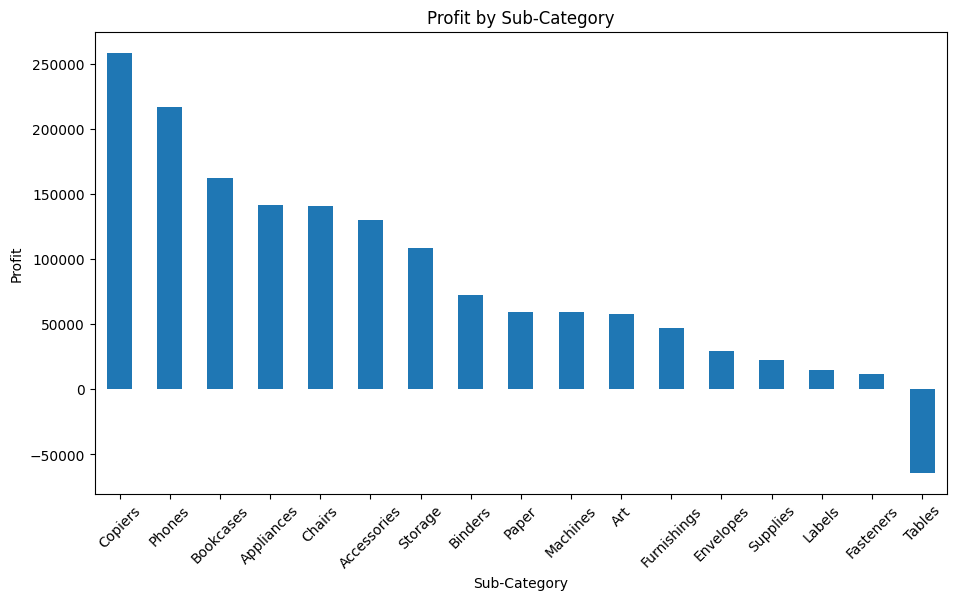

In [18]:
plt.figure(figsize=(11, 6))
profit_by_subcategory.plot(kind="bar")
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

## Top 5 Customers by Sales

This analysis identifies the top customers who generated the highest sales.

In [19]:
top_5_customers = (
    data.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_5_customers

Customer Name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Name: Sales, dtype: int64

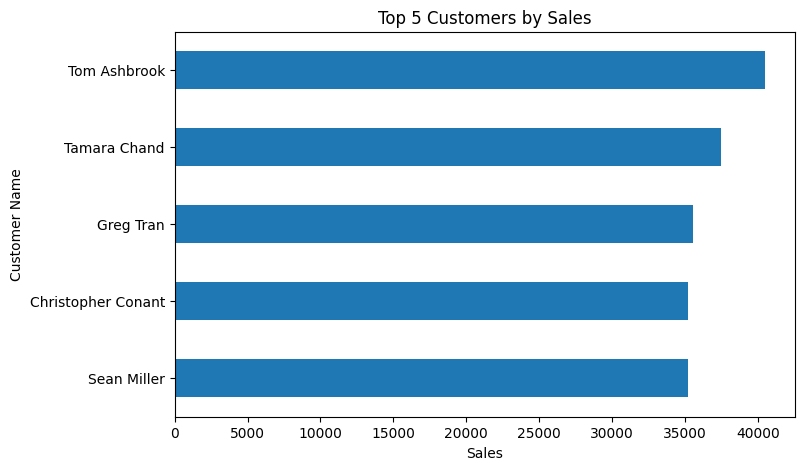

In [20]:
plt.figure(figsize=(8, 5))
top_5_customers.sort_values().plot(kind="barh")
plt.title("Top 5 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer Name")
plt.show()

## Segment-wise Performance

This section compares sales and profit across different customer segments.

In [21]:
segment_performance = (
    data.groupby("Segment")[["Sales", "Profit"]]
    .sum()
    .sort_values(by="Sales", ascending=False)
)

segment_performance

,Sales,Profit
Segment,,
Consumer,6508141,749239.78206
Corporate,3824808,441208.32866
Home Office,2309956,277009.18056


<Figure size 800x500 with 0 Axes>

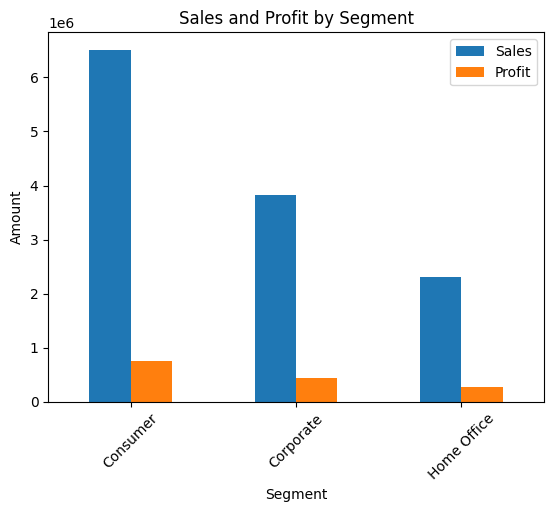

In [22]:
plt.figure(figsize=(8, 5))
segment_performance.plot(kind="bar")
plt.title("Sales and Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

## Monthly Sales Trend

This analysis shows how sales change over time on a monthly basis.

In [23]:
monthly_sales = (
    data
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

monthly_sales.head()

Order Date
2011-01-31     98902
2011-02-28     91152
2011-03-31    145726
2011-04-30    116927
2011-05-31    146762
Freq: ME, Name: Sales, dtype: int64

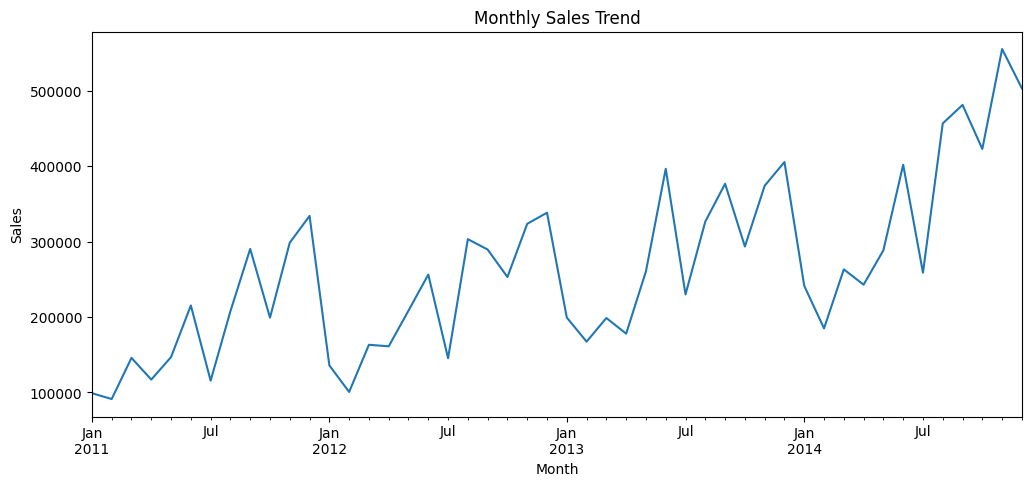

In [24]:
plt.figure(figsize=(12, 5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## Top 10 Products by Sales

This section identifies the products with the highest sales.

In [25]:
top_products = (
    data.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon imageCLASS 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, with Caller ID                           47880
Name: Sales, dtype: int64

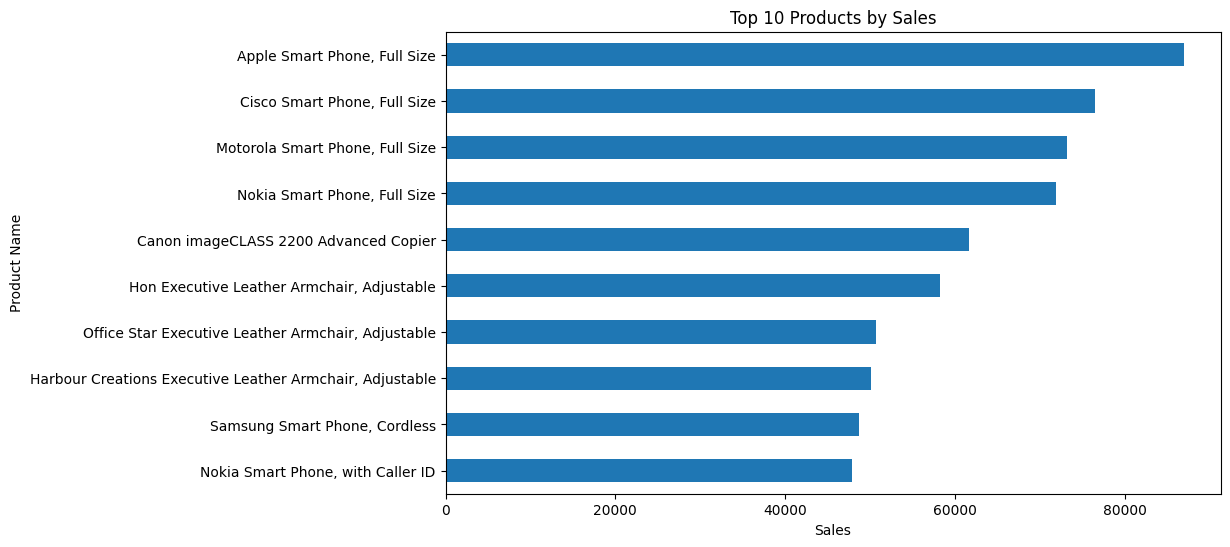

In [26]:
plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.show()

## Profit by Market

This analysis shows which markets generate the highest profit.

In [27]:
profit_by_market = (
    data.groupby("Market")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_market

Market
APAC      436000.04900
EU        372829.74150
US        286397.02170
LATAM     221643.48708
Africa     88871.63100
EMEA       43897.97100
Canada     17817.39000
Name: Profit, dtype: float64

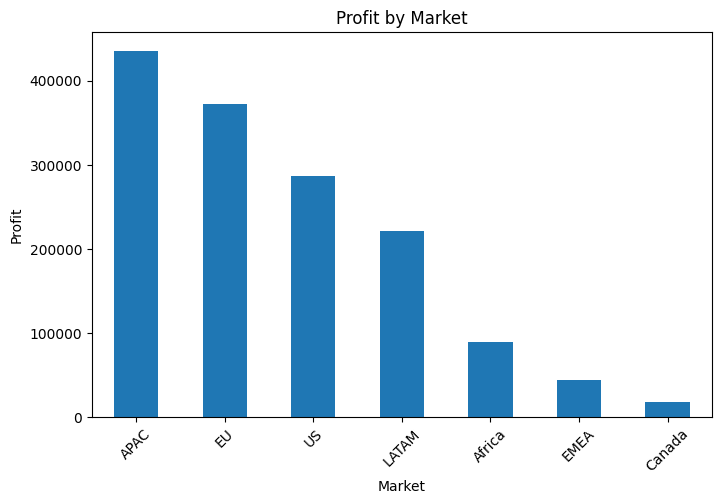

In [28]:
plt.figure(figsize=(8, 5))
profit_by_market.plot(kind="bar")
plt.title("Profit by Market")
plt.xlabel("Market")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

## Business Insights

This section summarizes the main business findings from the analysis.

In [29]:
best_region = sales_by_region.idxmax()
best_category = sales_by_category.idxmax()
best_customer = top_5_customers.idxmax()
highest_profit_subcategory = profit_by_subcategory.idxmax()
best_market = profit_by_market.idxmax()

print("Business Insights")
print("-----------------")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Best Region by Sales: {best_region}")
print(f"Best Category by Sales: {best_category}")
print(f"Top Customer by Sales: {best_customer}")
print(f"Highest Profit Sub-Category: {highest_profit_subcategory}")
print(f"Best Market by Profit: {best_market}")

Business Insights
-----------------
Total Sales: $12,642,905.00
Total Profit: $1,467,457.29
Profit Margin: 11.61%
Best Region by Sales: Central
Best Category by Sales: Technology
Top Customer by Sales: Tom Ashbrook
Highest Profit Sub-Category: Copiers
Best Market by Profit: APAC


In [30]:
print("Suggested Business Actions")
print("--------------------------")
print("1. Focus marketing campaigns on the highest-performing region.")
print("2. Give loyalty rewards to top customers.")
print("3. Promote profitable sub-categories more aggressively.")
print("4. Review low-profit or negative-profit sub-categories.")
print("5. Use segment-wise performance to target Consumer, Corporate, and Home Office customers separately.")

Suggested Business Actions
--------------------------
1. Focus marketing campaigns on the highest-performing region.
2. Give loyalty rewards to top customers.
3. Promote profitable sub-categories more aggressively.
4. Review low-profit or negative-profit sub-categories.
5. Use segment-wise performance to target Consumer, Corporate, and Home Office customers separately.


## Save Results

The cleaned dataset and analysis results are saved as CSV files for reporting and submission.

In [31]:
# Save cleaned dataset
data.to_csv("cleaned_global_superstore.csv", index=False)

# Save analysis outputs
kpi_summary.to_csv("kpi_summary.csv", index=False)
sales_by_region.to_csv("sales_by_region.csv")
sales_by_category.to_csv("sales_by_category.csv")
profit_by_subcategory.to_csv("profit_by_subcategory.csv")
top_5_customers.to_csv("top_5_customers.csv")
segment_performance.to_csv("segment_performance.csv")
monthly_sales.to_csv("monthly_sales_trend.csv")
top_products.to_csv("top_10_products.csv")
profit_by_market.to_csv("profit_by_market.csv")

print("Files saved successfully.")

Files saved successfully.


## Final Conclusion

In this task, the Global Superstore dataset was analyzed to understand sales, profit, customer behavior, product performance, regional performance, and market performance.

The data was cleaned, important columns were converted into proper formats, and missing important values were handled.

Several visualizations were created, including sales by region, sales by category, profit by sub-category, top customers, segment-wise performance, monthly sales trend, top products, and profit by market.

The analysis provides useful business insights such as the best-performing region, category, customer, market, and sub-category.

Overall, this task shows how business data analysis can help companies improve decision-making, customer targeting, and sales strategy.